# Evaluating the Robustness of SHAP and Anchor Explanations under Input Perturbations in Heart Disease Prediction
 Explainable AI (SOW-BKI266)  
 Cristina-Maria Filip (s1111439)

## 1. Setup loading data

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("heart.csv")
print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['target'].value_counts())
df.head()

Dataset shape: (303, 14)

Class distribution:
target
1    165
0    138
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 2. Preprocessing and Model Training

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

target_col = "target"
X = df.drop(columns=[target_col])
y = df[target_col]

numeric_features     = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=42))
])
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("F1 Score:", round(f1_score(y_test, y_pred), 3))
print("\n", classification_report(y_test, y_pred))

Accuracy: 0.754
F1 Score: 0.8

               precision    recall  f1-score   support

           0       0.84      0.57      0.68        28
           1       0.71      0.91      0.80        33

    accuracy                           0.75        61
   macro avg       0.78      0.74      0.74        61
weighted avg       0.77      0.75      0.75        61



## 3. SHAP Explanations

SHAP (SHapley Additive exPlanations) assigns each feature a contribution value for a specific 
prediction, grounded in cooperative game theory. A `TreeExplainer` is used here, which is 
efficient for tree-based models like Random Forests.

In [ ]:
import shap

#preprocessed feature space
rf_model     = model.named_steps["classifier"]
X_train_proc = model.named_steps["preprocessor"].transform(X_train)
X_test_proc  = model.named_steps["preprocessor"].transform(X_test)

#  readable feature names after one-hot encoding
ohe_feature_names = (
    model.named_steps["preprocessor"]
         .named_transformers_["cat"]
         .named_steps["onehot"]
         .get_feature_names_out(categorical_features)
)
all_feature_names = numeric_features + list(ohe_feature_names)

X_test_proc_df  = pd.DataFrame(X_test_proc,  columns=all_feature_names)
X_train_proc_df = pd.DataFrame(X_train_proc, columns=all_feature_names)

explainer        = shap.TreeExplainer(rf_model)
shap_explanation = explainer(X_test_proc_df)

print("SHAP values shape:", shap_explanation.values.shape)

SHAP values shape: (61, 26, 2)


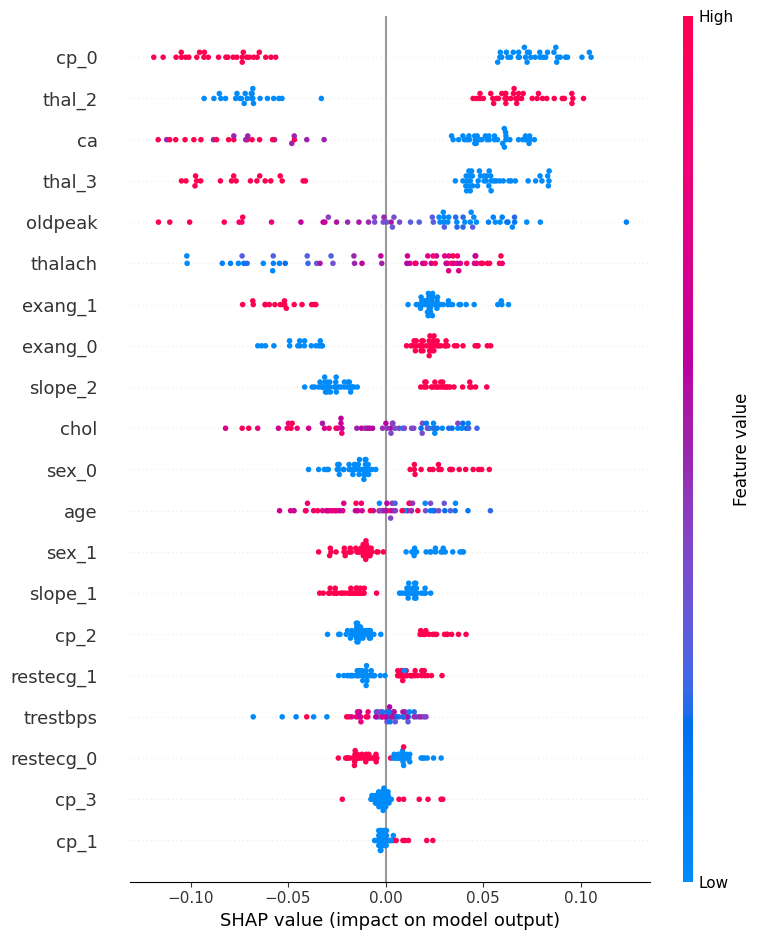

In [17]:
# global summary plot 
shap.summary_plot(
    shap_explanation.values[:, :, 1],
    X_test_proc_df
)


Prediction for instance 0: 0  (true label: 0)


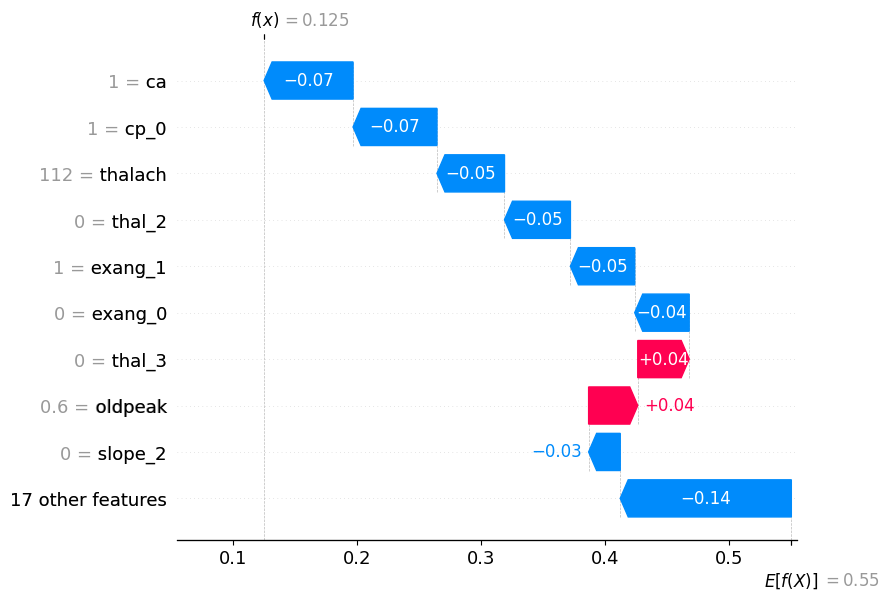

In [18]:
# Local waterfall plot for instance 0
i = 0
print(f"Prediction for instance {i}: {model.predict(X_test.iloc[[i]])[0]}  "
      f"(true label: {y_test.iloc[i]})")
shap.plots.waterfall(shap_explanation[i, :, 1])

## 4. Anchor Explanations

Anchors (Ribeiro et al., 2018) generate rule-based local explanations of the form 
*"IF condition A AND condition B THEN predict class X"*. Unlike SHAP values, anchors 
produce human-readable if-then rules that act as sufficient conditions for a given 
prediction. 

In [25]:
!pip install anchor-exp -q

In [26]:
from anchor import anchor_tabular
import numpy as np

# Wrap model.predict to accept numpy arrays
def predict_fn(x):
    return model.predict(pd.DataFrame(x, columns=X.columns))

anchor_explainer = anchor_tabular.AnchorTabularExplainer(
    class_names=['No Disease', 'Disease'],
    feature_names=list(X.columns),
    train_data=X_train.values,
    categorical_names={
        X.columns.get_loc(col): [str(v) for v in sorted(df[col].unique())]
        for col in categorical_features
    }
)
print("Anchor explainer fitted.")

Anchor explainer fitted.


In [27]:
i = 0
instance = X_test.values[i]

exp = anchor_explainer.explain_instance(
    instance,
    predict_fn,
    threshold=0.95
)

print(f"Instance {i} — predicted class: {predict_fn(instance.reshape(1, -1))[0]}")
print(f"True label: {y_test.iloc[i]}")
print()
print("Anchor rule:")
for condition in exp.names():
    print(f"  IF {condition}")
print(f"\nPrecision: {exp.precision():.3f}")
print(f"Coverage:  {exp.coverage():.3f}")

Instance 0 — predicted class: 0
True label: 0

Anchor rule:
  IF cp = 0
  IF exang = 1
  IF ca > 0.00

Precision: 0.954
Coverage:  0.166


## 5. Robustness Experiment: SHAP and Anchors under Input Perturbations

To evaluate robustness, small Gaussian noise is added to the **numeric features** of each 
test instance, simulating natural measurement variability (e.g., slight differences in blood 
pressure or cholesterol readings between devices). Explanations before and after perturbation 
are then compared.

- **SHAP robustness metric:** Top-k feature overlap — the proportion of the top-5 most 
  important features that remain the same after perturbation.
- **Anchor robustness metric:** Rule stability — Jaccard similarity between the set of rule 
  conditions before and after perturbation.

In [ ]:
np.random.seed(42)

# Per-feature standard deviation to scale noise proportionally
numeric_stds = X_train[numeric_features].std().values

def perturb_instance(row_series, noise_level=0.05):
    """add Gaussian noise to numeric features only."""
    row = row_series.copy()
    noise = np.random.normal(0, noise_level * numeric_stds, size=len(numeric_features))
    row[numeric_features] += noise
    return row

def shap_top_k_overlap(shap_orig, shap_pert, k=5):
    """proportion of top-k features shared before and after perturbation."""
    top_orig = set(np.argsort(np.abs(shap_orig))[-k:])
    top_pert = set(np.argsort(np.abs(shap_pert))[-k:])
    return len(top_orig & top_pert) / k

def anchor_rule_stability(rules_orig, rules_pert):
    """Jaccard similarity between two sets of anchor rule conditions."""
    set_orig = set(rules_orig)
    set_pert = set(rules_pert)
    if not set_orig and not set_pert:
        return 1.0
    if not set_orig or not set_pert:
        return 0.0
    return len(set_orig & set_pert) / len(set_orig | set_pert)

print("Helper functions defined.")

Helper functions defined.


In [ ]:
# Use N_INTANCES = 10 for quicker run
N_INSTANCES  = 30
NOISE_LEVELS = [0.01, 0.05, 0.10, 0.20]
K = 5

shap_overlaps      = {nl: [] for nl in NOISE_LEVELS}
anchor_stabilities = {nl: [] for nl in NOISE_LEVELS}

for nl in NOISE_LEVELS:
    print(f"\nNoise level: {nl}")
    for i in range(N_INSTANCES):
        #SHAP explanation
        orig_row     = X_test.iloc[[i]]
        orig_proc    = model.named_steps["preprocessor"].transform(orig_row)
        orig_proc_df = pd.DataFrame(orig_proc, columns=all_feature_names)
        shap_orig    = explainer(orig_proc_df).values[0, :, 1]

        #Anchor explanation
        anchor_orig = anchor_explainer.explain_instance(
            X_test.values[i], predict_fn, threshold=0.95
        )

        #Perturbed SHAP explanation 
        pert_row     = perturb_instance(X_test.iloc[i], noise_level=nl).to_frame().T
        pert_proc    = model.named_steps["preprocessor"].transform(pert_row)
        pert_proc_df = pd.DataFrame(pert_proc, columns=all_feature_names)
        shap_pert    = explainer(pert_proc_df).values[0, :, 1]

        #Perturbed Anchor explanation
        anchor_pert = anchor_explainer.explain_instance(
            pert_row.values[0], predict_fn, threshold=0.95
        )

        #Store metrics
        shap_overlaps[nl].append(shap_top_k_overlap(shap_orig, shap_pert, k=K))
        anchor_stabilities[nl].append(
            anchor_rule_stability(anchor_orig.names(), anchor_pert.names())
        )

    print(f"  SHAP top-{K} overlap:    "
          f"{np.mean(shap_overlaps[nl]):.3f} ± {np.std(shap_overlaps[nl]):.3f}")
    print(f"  Anchor rule stability:  "
          f"{np.mean(anchor_stabilities[nl]):.3f} ± {np.std(anchor_stabilities[nl]):.3f}")


Noise level: 0.01
  SHAP top-5 overlap:    0.987 ± 0.050
  Anchor rule stability:  0.721 ± 0.308

Noise level: 0.05
  SHAP top-5 overlap:    0.973 ± 0.068
  Anchor rule stability:  0.688 ± 0.329

Noise level: 0.1
  SHAP top-5 overlap:    0.973 ± 0.068
  Anchor rule stability:  0.671 ± 0.339

Noise level: 0.2
  SHAP top-5 overlap:    0.933 ± 0.094
  Anchor rule stability:  0.600 ± 0.315


## 6. Results Visualisation

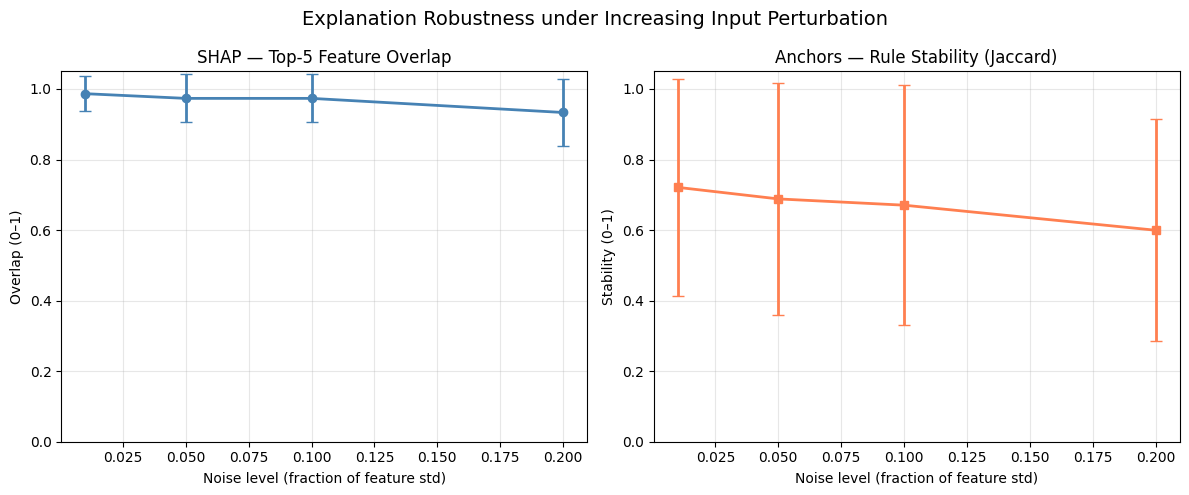

Figure saved to robustness_results.png


In [30]:
means_shap   = [np.mean(shap_overlaps[nl])      for nl in NOISE_LEVELS]
stds_shap    = [np.std(shap_overlaps[nl])       for nl in NOISE_LEVELS]
means_anchor = [np.mean(anchor_stabilities[nl]) for nl in NOISE_LEVELS]
stds_anchor  = [np.std(anchor_stabilities[nl])  for nl in NOISE_LEVELS]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Explanation Robustness under Increasing Input Perturbation", fontsize=14)

axes[0].errorbar(NOISE_LEVELS, means_shap, yerr=stds_shap,
                 marker='o', color='steelblue', capsize=4, linewidth=2)
axes[0].set_title(f"SHAP — Top-{K} Feature Overlap")
axes[0].set_xlabel("Noise level (fraction of feature std)")
axes[0].set_ylabel("Overlap (0–1)")
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)

axes[1].errorbar(NOISE_LEVELS, means_anchor, yerr=stds_anchor,
                 marker='s', color='coral', capsize=4, linewidth=2)
axes[1].set_title("Anchors — Rule Stability (Jaccard)")
axes[1].set_xlabel("Noise level (fraction of feature std)")
axes[1].set_ylabel("Stability (0–1)")
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("robustness_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to robustness_results.png")

In [31]:
results_df = pd.DataFrame({
    "Noise level"            : NOISE_LEVELS,
    "SHAP overlap (mean)"    : [round(np.mean(shap_overlaps[nl]), 3)      for nl in NOISE_LEVELS],
    "SHAP overlap (std)"     : [round(np.std(shap_overlaps[nl]), 3)       for nl in NOISE_LEVELS],
    "Anchor stability (mean)": [round(np.mean(anchor_stabilities[nl]), 3) for nl in NOISE_LEVELS],
    "Anchor stability (std)" : [round(np.std(anchor_stabilities[nl]), 3)  for nl in NOISE_LEVELS],
})
print(results_df.to_string(index=False))

 Noise level  SHAP overlap (mean)  SHAP overlap (std)  Anchor stability (mean)  Anchor stability (std)
        0.01                0.987               0.050                    0.721                   0.308
        0.05                0.973               0.068                    0.688                   0.329
        0.10                0.973               0.068                    0.671                   0.339
        0.20                0.933               0.094                    0.600                   0.315
